### Load and prepare the Adult dataset

In [14]:
# Step 1.1 - Imports
import pandas as pd
import numpy as np

from pathlib import Path

In [15]:
# Step 1.2 - Column names for adult.data
columns = [
    "age", "workclass", "fnlwgt", "education", "education-num",
    "marital-status", "occupation", "relationship", "race", "sex",
    "capital-gain", "capital-loss", "hours-per-week", "native-country", "income"
]

In [17]:
# Step 1.3 - Load adult.data
# Update the path if your file is stored elsewhere
data_path = Path("adult_dataset/adult.data")

df = pd.read_csv(
    data_path,
    header=None,
    names=columns,
    na_values=" ?",
    skipinitialspace=True
)

print("Shape before cleaning:", df.shape)
df.head()

Shape before cleaning: (32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [18]:
# Step 1.4 - Basic cleaning
# Remove rows with missing values
df = df.dropna().reset_index(drop=True)

# Clean income labels if needed
df["income"] = df["income"].astype(str).str.strip()

print("Shape after cleaning:", df.shape)
print("\nIncome distribution:")
print(df["income"].value_counts())

Shape after cleaning: (32561, 15)

Income distribution:
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


In [19]:
# Step 1.5 - Select numerical QI and SA
qi_cols = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

sa_col = "income"

df_num_qi = df[qi_cols + [sa_col]].copy()

print("Selected columns:")
print(df_num_qi.columns.tolist())
df_num_qi.head()

Selected columns:
['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week', 'income']


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,77516,13,2174,0,40,<=50K
1,50,83311,13,0,0,13,<=50K
2,38,215646,9,0,0,40,<=50K
3,53,234721,7,0,0,40,<=50K
4,28,338409,13,0,0,40,<=50K


In [20]:
# Step 1.6 - Quick data inspection
print(df_num_qi.describe())

print("\nUnique SA values:")
print(df_num_qi[sa_col].unique())

                age        fnlwgt  education-num  capital-gain  capital-loss  \
count  32561.000000  3.256100e+04   32561.000000  32561.000000  32561.000000   
mean      38.581647  1.897784e+05      10.080679   1077.648844     87.303830   
std       13.640433  1.055500e+05       2.572720   7385.292085    402.960219   
min       17.000000  1.228500e+04       1.000000      0.000000      0.000000   
25%       28.000000  1.178270e+05       9.000000      0.000000      0.000000   
50%       37.000000  1.783560e+05      10.000000      0.000000      0.000000   
75%       48.000000  2.370510e+05      12.000000      0.000000      0.000000   
max       90.000000  1.484705e+06      16.000000  99999.000000   4356.000000   

       hours-per-week  
count    32561.000000  
mean        40.437456  
std         12.347429  
min          1.000000  
25%         40.000000  
50%         40.000000  
75%         45.000000  
max         99.000000  

Unique SA values:
<StringArray>
['<=50K', '>50K']
Length: 2, d

In [21]:
# Step 1.7 - Optional: encode SA for later ML use
# <=50K -> 0, >50K -> 1
income_map = {"<=50K": 0, ">50K": 1}
df_num_qi["income_binary"] = df_num_qi["income"].map(income_map)

print(df_num_qi[["income", "income_binary"]].drop_duplicates())
df_num_qi.head()

  income  income_binary
0  <=50K              0
7   >50K              1


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income,income_binary
0,39,77516,13,2174,0,40,<=50K,0
1,50,83311,13,0,0,13,<=50K,0
2,38,215646,9,0,0,40,<=50K,0
3,53,234721,7,0,0,40,<=50K,0
4,28,338409,13,0,0,40,<=50K,0


### Implement Mondrian k-anonymity for numerical QI only

In [22]:
# Step 2.1 - Keep only QI + SA for anonymization
work_df = df_num_qi[qi_cols + [sa_col]].copy()
work_df.head()

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,39,77516,13,2174,0,40,<=50K
1,50,83311,13,0,0,13,<=50K
2,38,215646,9,0,0,40,<=50K
3,53,234721,7,0,0,40,<=50K
4,28,338409,13,0,0,40,<=50K


In [23]:
# Step 2.2 - Helper functions for Mondrian
import numpy as np
import pandas as pd

In [24]:
def normalized_width(df, col, global_min, global_max):
    """
    Compute normalized range width of a column inside a partition.
    """
    if global_max[col] == global_min[col]:
        return 0.0
    
    part_min = df[col].min()
    part_max = df[col].max()
    return (part_max - part_min) / (global_max[col] - global_min[col])

def choose_split_dimension(df, qi_cols, global_min, global_max):
    """
    Choose the dimension with the largest normalized width.
    """
    widths = {
        col: normalized_width(df, col, global_min, global_max)
        for col in qi_cols
    }
    split_col = max(widths, key=widths.get)
    return split_col, widths

def split_partition(df, split_col):
    """
    Split a partition into two parts using the median of the split column.
    """
    sorted_df = df.sort_values(by=split_col).reset_index(drop=True)
    mid = len(sorted_df) // 2
    
    left = sorted_df.iloc[:mid].copy()
    right = sorted_df.iloc[mid:].copy()
    
    return left, right

def can_split(df, k):
    """
    A partition can be split only if both child partitions can have at least k records.
    """
    return len(df) >= 2 * k

In [25]:
# Step 2.3 — Recursive Mondrian partitioning
def mondrian_partition(df, qi_cols, k, global_min, global_max):
    """
    Recursively partition data using Mondrian k-anonymity.
    Returns a list of final partitions.
    """
    # Stop if not enough records to split into 2 valid children
    if not can_split(df, k):
        return [df]
    
    split_col, widths = choose_split_dimension(df, qi_cols, global_min, global_max)
    
    # If all widths are zero, no meaningful split is possible
    if widths[split_col] == 0:
        return [df]
    
    left, right = split_partition(df, split_col)
    
    # If split violates k-anonymity, stop
    if len(left) < k or len(right) < k:
        return [df]
    
    return (
        mondrian_partition(left, qi_cols, k, global_min, global_max) +
        mondrian_partition(right, qi_cols, k, global_min, global_max)
    )

In [26]:
# Step 2.4 — Generalize each partition into intervals
def interval_string(min_val, max_val):
    if min_val == max_val:
        return str(min_val)
    return f"[{min_val}, {max_val}]"

def generalize_partition(df_part, qi_cols):
    """
    Replace QI values in a partition with interval strings.
    """
    gen_df = df_part.copy()
    
    for col in qi_cols:
        min_val = df_part[col].min()
        max_val = df_part[col].max()
        gen_value = interval_string(min_val, max_val)
        gen_df[col] = gen_value
    
    return gen_df

def anonymize_with_mondrian(df, qi_cols, sa_col, k):
    """
    Apply Mondrian partitioning and return:
    - anonymized dataframe
    - final partitions
    """
    df = df.reset_index(drop=True).copy()
    
    global_min = {col: df[col].min() for col in qi_cols}
    global_max = {col: df[col].max() for col in qi_cols}
    
    partitions = mondrian_partition(df, qi_cols, k, global_min, global_max)
    
    anon_parts = []
    for part in partitions:
        anon_parts.append(generalize_partition(part, qi_cols))
    
    anon_df = pd.concat(anon_parts, axis=0).reset_index(drop=True)
    
    return anon_df, partitions

In [27]:
# Step 2.5 — Test with one k value
k = 5
anon_df_k5, partitions_k5 = anonymize_with_mondrian(work_df, qi_cols, sa_col, k)

print("Original shape:", work_df.shape)
print("Anonymized shape:", anon_df_k5.shape)
print("Number of final partitions:", len(partitions_k5))
print("Min partition size:", min(len(p) for p in partitions_k5))
print("Max partition size:", max(len(p) for p in partitions_k5))

Original shape: (32561, 7)
Anonymized shape: (32561, 7)
Number of final partitions: 4096
Min partition size: 7
Max partition size: 8


In [28]:
anon_df_k5.head(10)

,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,income
0,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
1,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
2,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
3,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
4,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
5,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
6,"[18, 33]","[39054, 184135]",9,0,0,"[1, 20]",<=50K
7,"[18, 36]","[33397, 180052]","[9, 10]",0,0,"[20, 36]",<=50K
8,"[18, 36]","[33397, 180052]","[9, 10]",0,0,"[20, 36]",<=50K
9,"[18, 36]","[33397, 180052]","[9, 10]",0,0,"[20, 36]",<=50K


In [29]:
# Step 2.6 - Verify equivalence class sizes
eq_sizes = anon_df_k5.groupby(qi_cols).size().reset_index(name="group_size")
eq_sizes = eq_sizes.sort_values("group_size")

print(eq_sizes.head(10))
print("\nMinimum equivalence class size:", eq_sizes["group_size"].min())

           age            fnlwgt education-num  capital-gain capital-loss  \
3316  [47, 51]  [175339, 237819]            13             0            0   
2287  [37, 45]   [24763, 160647]      [10, 13]  [4064, 7298]            0   
2288  [37, 45]   [25649, 147206]      [10, 12]  [4386, 7688]            0   
212   [17, 36]  [113654, 170070]        [6, 9]             0            0   
3247  [46, 54]  [100067, 178013]        [6, 7]             0            0   
2745  [39, 52]   [59590, 247733]       [9, 10]             0            0   
2746  [39, 52]   [89508, 145155]             9             0            0   
3687  [54, 56]   [87205, 164332]             9             0            0   
3254  [46, 57]  [127089, 328216]            10  [4386, 7688]            0   
2297  [37, 45]   [76878, 177905]        [3, 9]  [3103, 5455]            0   

     hours-per-week  group_size  
3316       [40, 50]           7  
2287       [15, 40]           7  
2288       [45, 50]           7  
212         [4, 

In [30]:
# Step 2.7 — Generate anonymized datasets for multiple k values
k_values = [2, 5, 10, 20, 50, 100]

anonymized_results = {}
partition_info = []

for k in k_values:
    anon_df, partitions = anonymize_with_mondrian(work_df, qi_cols, sa_col, k)
    anonymized_results[k] = anon_df
    
    eq_sizes = anon_df.groupby(qi_cols).size().reset_index(name="group_size")
    
    partition_info.append({
        "k": k,
        "num_partitions": len(partitions),
        "min_partition_size": min(len(p) for p in partitions),
        "max_partition_size": max(len(p) for p in partitions),
        "avg_partition_size": np.mean([len(p) for p in partitions]),
        "min_equivalence_class_size": eq_sizes["group_size"].min()
    })

partition_summary = pd.DataFrame(partition_info)
partition_summary

,k,num_partitions,min_partition_size,max_partition_size,avg_partition_size,min_equivalence_class_size
0,2,16177,2,3,2.012796,2
1,5,4096,7,8,7.949463,7
2,10,2048,15,16,15.898926,15
3,20,1024,31,32,31.797852,31
4,50,512,63,64,63.595703,63
5,100,256,127,128,127.191406,127


In [31]:
# Step 2.8 — Save full datasets with anonymized QI
full_anonymized_results = {}

for k, anon_qi_df in anonymized_results.items():
    # Create a copy of original full dataset
    full_df = df.copy().reset_index(drop=True)
    
    # Replace QI columns with anonymized values
    for col in qi_cols:
        full_df[col] = anon_qi_df[col]
    
    full_anonymized_results[k] = full_df
    
    # Save full dataset
    full_df.to_csv(f"adult_full_mondrian_k{k}.csv", index=False)

print("Saved FULL anonymized datasets (all columns included).")

Saved FULL anonymized datasets (all columns included).


### Convert anonymized intervals into ML-ready numeric features and prepare train/test data.

In [32]:
# Step 3.1 — Load the original full dataset and the anonymized full datasets
import pandas as pd
import numpy as np
import re

In [33]:
# Original full dataset from Step 1
original_full_df = df.copy().reset_index(drop=True)

print(original_full_df.shape)
original_full_df.head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


In [34]:
# If needed, reload anonymized full datasets from saved CSV files
k_values = [2, 5, 10, 20, 50, 100]

full_anonymized_results = {}
for k in k_values:
    full_anonymized_results[k] = pd.read_csv(f"adult_full_mondrian_k{k}.csv")

print(full_anonymized_results[5].shape)
full_anonymized_results[5].head()

(32561, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,"[18, 33]",State-gov,"[39054, 184135]",Bachelors,9,Never-married,Adm-clerical,Not-in-family,White,Male,0,0,"[1, 20]",United-States,<=50K
1,"[18, 33]",Self-emp-not-inc,"[39054, 184135]",Bachelors,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,"[1, 20]",United-States,<=50K
2,"[18, 33]",Private,"[39054, 184135]",HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,"[1, 20]",United-States,<=50K
3,"[18, 33]",Private,"[39054, 184135]",11th,9,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,"[1, 20]",United-States,<=50K
4,"[18, 33]",Private,"[39054, 184135]",Bachelors,9,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,"[1, 20]",Cuba,<=50K


In [35]:
# Step 3.2 — Define target and feature columns
target_col = "income"
feature_cols = [col for col in original_full_df.columns if col != target_col]

print("Number of features:", len(feature_cols))
print(feature_cols)

Number of features: 14
['age', 'workclass', 'fnlwgt', 'education', 'education-num', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country']


In [36]:
# Step 3.3 — Convert interval strings to numeric values
def parse_interval_to_midpoint(x):
    """
    Convert a scalar or interval string into a numeric midpoint.
    
    Examples:
    39 -> 39.0
    "39" -> 39.0
    "[25, 37]" -> 31.0
    """
    if pd.isna(x):
        return np.nan
    
    # already numeric
    if isinstance(x, (int, float, np.integer, np.floating)):
        return float(x)
    
    x = str(x).strip()
    
    # interval format: [a, b]
    if x.startswith("[") and x.endswith("]"):
        nums = re.findall(r"-?\d+\.?\d*", x)
        if len(nums) == 2:
            a, b = map(float, nums)
            return (a + b) / 2.0
    
    # single numeric value stored as string
    try:
        return float(x)
    except ValueError:
        return np.nan

In [37]:
# Step 3.4 — Apply midpoint conversion to QI columns
def convert_qi_intervals_to_midpoints(df_input, qi_cols):
    df_out = df_input.copy()
    
    for col in qi_cols:
        df_out[col] = df_out[col].apply(parse_interval_to_midpoint)
    
    return df_out

# Test on one anonymized dataset
test_k = 5
converted_k5 = convert_qi_intervals_to_midpoints(full_anonymized_results[test_k], qi_cols)

print(converted_k5[qi_cols].head())
print(converted_k5[qi_cols].dtypes)

    age    fnlwgt  education-num  capital-gain  capital-loss  hours-per-week
0  25.5  111594.5            9.0           0.0           0.0            10.5
1  25.5  111594.5            9.0           0.0           0.0            10.5
2  25.5  111594.5            9.0           0.0           0.0            10.5
3  25.5  111594.5            9.0           0.0           0.0            10.5
4  25.5  111594.5            9.0           0.0           0.0            10.5
age               float64
fnlwgt            float64
education-num     float64
capital-gain      float64
capital-loss      float64
hours-per-week    float64
dtype: object


In [38]:
# Step 3.5 — Prepare original and anonymized datasets in a consistent format
income_map = {"<=50K": 0, ">50K": 1}

def prepare_dataset_for_ml(df_input, qi_cols, target_col="income"):
    df_out = df_input.copy()
    
    # Convert interval-based QI columns if needed
    df_out = convert_qi_intervals_to_midpoints(df_out, qi_cols)
    
    # Encode target
    df_out["income_binary"] = df_out[target_col].map(income_map)
    
    return df_out

prepared_original_df = prepare_dataset_for_ml(original_full_df, qi_cols, target_col)
prepared_anonymized_results = {
    k: prepare_dataset_for_ml(df_k, qi_cols, target_col)
    for k, df_k in full_anonymized_results.items()
}

print(prepared_original_df.shape)
print(prepared_anonymized_results[5].shape)
prepared_anonymized_results[5].head()

(32561, 16)
(32561, 16)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income,income_binary
0,25.5,State-gov,111594.5,Bachelors,9.0,Never-married,Adm-clerical,Not-in-family,White,Male,0.0,0.0,10.5,United-States,<=50K,0
1,25.5,Self-emp-not-inc,111594.5,Bachelors,9.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,10.5,United-States,<=50K,0
2,25.5,Private,111594.5,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,10.5,United-States,<=50K,0
3,25.5,Private,111594.5,11th,9.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,10.5,United-States,<=50K,0
4,25.5,Private,111594.5,Bachelors,9.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,10.5,Cuba,<=50K,0


In [39]:
# Step 3.6 — Separate X and y
def split_X_y(df_input, target_binary_col="income_binary", drop_target_col="income"):
    X = df_input.drop(columns=[drop_target_col, target_binary_col])
    y = df_input[target_binary_col].copy()
    return X, y

X_original, y_original = split_X_y(prepared_original_df)

print("Original X shape:", X_original.shape)
print("Original y shape:", y_original.shape)
print(X_original.head())

Original X shape: (32561, 14)
Original y shape: (32561,)
    age         workclass    fnlwgt  education  education-num  \
0  39.0         State-gov   77516.0  Bachelors           13.0   
1  50.0  Self-emp-not-inc   83311.0  Bachelors           13.0   
2  38.0           Private  215646.0    HS-grad            9.0   
3  53.0           Private  234721.0       11th            7.0   
4  28.0           Private  338409.0  Bachelors           13.0   

       marital-status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital-gain  capital-loss  hours-per-week native-country  
0        2174.0           0.0            40.

In [40]:
# Step 3.7 — Identify numeric and categorical predictors
numeric_features = X_original.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_original.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("\nCategorical features:", categorical_features)

Numeric features: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']

Categorical features: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


In [41]:
# Step 3.8 — Build the preprocessing transformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [42]:
# Step 3.9 — Make a fixed train/test split for fair comparison
from sklearn.model_selection import train_test_split

all_indices = np.arange(len(prepared_original_df))

train_idx, test_idx = train_test_split(
    all_indices,
    test_size=0.2,
    random_state=42,
    stratify=prepared_original_df["income_binary"]
)

print("Train size:", len(train_idx))
print("Test size:", len(test_idx))

Train size: 26048
Test size: 6513


In [43]:
# Step 3.10 — Create reusable train/test datasets for original and anonymized data
def build_train_test_dict(df_input, train_idx, test_idx, target_col="income", target_binary_col="income_binary"):
    X, y = split_X_y(df_input, target_binary_col=target_binary_col, drop_target_col=target_col)
    
    X_train = X.iloc[train_idx].reset_index(drop=True)
    X_test = X.iloc[test_idx].reset_index(drop=True)
    y_train = y.iloc[train_idx].reset_index(drop=True)
    y_test = y.iloc[test_idx].reset_index(drop=True)
    
    return {
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test
    }

dataset_splits = {
    "original": build_train_test_dict(prepared_original_df, train_idx, test_idx)
}

for k, df_k in prepared_anonymized_results.items():
    dataset_splits[f"k={k}"] = build_train_test_dict(df_k, train_idx, test_idx)

print(dataset_splits.keys())
print(dataset_splits["original"]["X_train"].shape)
print(dataset_splits["k=5"]["X_train"].shape)

dict_keys(['original', 'k=2', 'k=5', 'k=10', 'k=20', 'k=50', 'k=100'])
(26048, 14)
(26048, 14)


In [44]:
# Step 3.11 — Optional sanity check
sample_rows = [0, 1, 2, 3, 4]

print("Original:")
display(prepared_original_df.loc[sample_rows, qi_cols + ["education", "occupation", "income"]])

print("Anonymized k=5:")
display(prepared_anonymized_results[5].loc[sample_rows, qi_cols + ["education", "occupation", "income"]])

Original:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,education,occupation,income
0,39.0,77516.0,13.0,2174.0,0.0,40.0,Bachelors,Adm-clerical,<=50K
1,50.0,83311.0,13.0,0.0,0.0,13.0,Bachelors,Exec-managerial,<=50K
2,38.0,215646.0,9.0,0.0,0.0,40.0,HS-grad,Handlers-cleaners,<=50K
3,53.0,234721.0,7.0,0.0,0.0,40.0,11th,Handlers-cleaners,<=50K
4,28.0,338409.0,13.0,0.0,0.0,40.0,Bachelors,Prof-specialty,<=50K


Anonymized k=5:


,age,fnlwgt,education-num,capital-gain,capital-loss,hours-per-week,education,occupation,income
0,25.5,111594.5,9.0,0.0,0.0,10.5,Bachelors,Adm-clerical,<=50K
1,25.5,111594.5,9.0,0.0,0.0,10.5,Bachelors,Exec-managerial,<=50K
2,25.5,111594.5,9.0,0.0,0.0,10.5,HS-grad,Handlers-cleaners,<=50K
3,25.5,111594.5,9.0,0.0,0.0,10.5,11th,Handlers-cleaners,<=50K
4,25.5,111594.5,9.0,0.0,0.0,10.5,Bachelors,Prof-specialty,<=50K


### Build the evaluation framework + first model (Logistic Regression)

In [45]:
# Step 4.1 — Import evaluation tools
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    confusion_matrix
)

In [46]:
# Step 4.2 — Define evaluation metrics function
def evaluate_classification(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    mis = 1 - acc
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec = recall_score(y_true, y_pred, zero_division=0)
    
    try:
        auc = roc_auc_score(y_true, y_prob)
    except:
        auc = np.nan
    
    return {
        "accuracy": acc,
        "misclassification_rate": mis,
        "precision": prec,
        "recall": rec,
        "auc": auc
    }

In [47]:
# Step 4.3 — Build Logistic Regression pipeline
logreg_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        solver="lbfgs"
    ))
])

In [48]:
# Step 4.4 — Train & evaluate on one dataset (sanity check)
data_original = dataset_splits["original"]

X_train = data_original["X_train"]
X_test = data_original["X_test"]
y_train = data_original["y_train"]
y_test = data_original["y_test"]

logreg_pipeline.fit(X_train, y_train)

y_pred = logreg_pipeline.predict(X_test)
y_prob = logreg_pipeline.predict_proba(X_test)[:, 1]

metrics_original = evaluate_classification(y_test, y_pred, y_prob)
metrics_original

{'accuracy': 0.855980346998311,
 'misclassification_rate': 0.14401965300168895,
 'precision': 0.7397260273972602,
 'recall': 0.6198979591836735,
 'auc': 0.909838452570108}

In [49]:
# Step 4.5 — Evaluate across all k values
results_logreg = []

for name, data in dataset_splits.items():
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    
    model = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(max_iter=1000, solver="lbfgs"))
    ])
    
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    metrics = evaluate_classification(y_test, y_pred, y_prob)
    
    metrics["dataset"] = name
    
    # extract k value
    if name == "original":
        metrics["k"] = 0
    else:
        metrics["k"] = int(name.split("=")[1])
    
    results_logreg.append(metrics)

results_logreg_df = pd.DataFrame(results_logreg).sort_values("k")
results_logreg_df

,accuracy,misclassification_rate,precision,recall,auc,dataset,k
0,0.855980,0.144020,0.739726,0.619898,0.909838,original,0
1,0.832949,0.167051,0.702020,0.531888,0.880588,k=2,2
2,0.833257,0.166743,0.702181,0.533801,0.880829,k=5,5
3,0.833564,0.166436,0.703361,0.533801,0.880958,k=10,10
4,0.833257,0.166743,0.702521,0.533163,0.880574,k=20,20
5,0.831875,0.168125,0.699578,0.528699,0.880472,k=50,50
6,0.832642,0.167358,0.700840,0.531888,0.880728,k=100,100


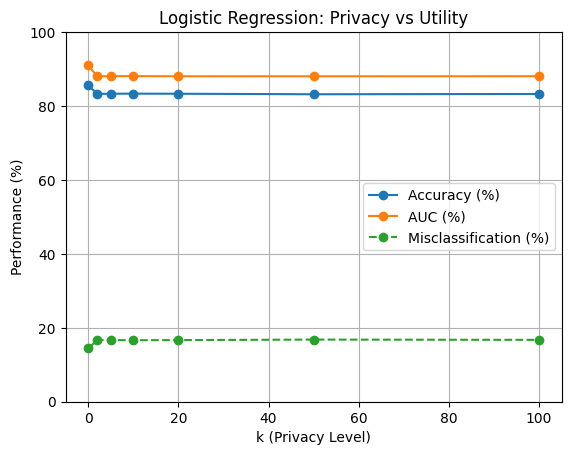

In [52]:
# Step 4.6 — Visualize the impact of k
import matplotlib.pyplot as plt

mis_pct = results_logreg_df["misclassification_rate"] * 100
accuracy_pct = results_logreg_df["accuracy"] * 100
auc_pct = results_logreg_df["auc"] * 100

plt.figure()

plt.plot(results_logreg_df["k"], accuracy_pct, marker="o", label="Accuracy (%)")
plt.plot(results_logreg_df["k"], auc_pct, marker="o", label="AUC (%)")
plt.plot(results_logreg_df["k"], mis_pct, marker="o", linestyle="--", label="Misclassification (%)")

plt.xlabel("k (Privacy Level)")
plt.ylabel("Performance (%)")
plt.title("Logistic Regression: Privacy vs Utility")

plt.ylim(0, 100)

plt.legend()
plt.grid()

plt.show()

### Run all classical ML models and compare results across k

In [53]:
# Step 5.1 — Import models
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB

In [56]:
# Step 5.2 — Define model configurations
models = {
    "LogisticRegression": LogisticRegression(max_iter=1000, solver="lbfgs"),
    
    "RandomForest": RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        random_state=42,
        n_jobs=-1
    ),
    
    "SVM": SVC(
        kernel="rbf",
        probability=True,
        C=1.0,
        gamma="scale"
    ),
    
    "MLP": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        max_iter=200,
        random_state=42
    )
}

In [57]:
# Step 5.3 — General evaluation loop
all_results = []

for model_name, model in models.items():
    print(f"Running model: {model_name}")
    
    for dataset_name, data in dataset_splits.items():
        X_train = data["X_train"]
        X_test = data["X_test"]
        y_train = data["y_train"]
        y_test = data["y_test"]
        
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        
        metrics = evaluate_classification(y_test, y_pred, y_prob)
        
        # Add identifiers
        metrics["model"] = model_name
        metrics["dataset"] = dataset_name
        
        if dataset_name == "original":
            metrics["k"] = 0
        else:
            metrics["k"] = int(dataset_name.split("=")[1])
        
        all_results.append(metrics)

Running model: LogisticRegression
Running model: RandomForest
Running model: SVM
Running model: MLP


/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2

In [83]:
# Step 5.4 — Create results DataFrame
results_df = pd.DataFrame(all_results)
results_df = results_df.sort_values(["model", "k"])

results_df.head(20)

,accuracy,misclassification_rate,precision,recall,auc,model,dataset,k
0,0.855980,0.144020,0.739726,0.619898,0.909838,LogisticRegression,original,0
1,0.832949,0.167051,0.702020,0.531888,0.880588,LogisticRegression,k=2,2
2,0.833257,0.166743,0.702181,0.533801,0.880829,LogisticRegression,k=5,5
3,0.833564,0.166436,0.703361,0.533801,0.880958,LogisticRegression,k=10,10
4,0.833257,0.166743,0.702521,0.533163,0.880574,LogisticRegression,k=20,20
5,0.831875,0.168125,0.699578,0.528699,0.880472,LogisticRegression,k=50,50
6,0.832642,0.167358,0.700840,0.531888,0.880728,LogisticRegression,k=100,100
21,0.843237,0.156763,0.708302,0.593112,0.887854,MLP,original,0
22,0.805312,0.194688,0.613293,0.517857,0.835718,MLP,k=2,2
23,0.799324,0.200676,0.596452,0.514668,0.834744,MLP,k=5,5


In [85]:
# Step 5.5 — Pivot table for easy comparison
pivot_accuracy = results_df.pivot_table(
    index="k",
    columns="model",
    values="accuracy"
)

pivot_auc = results_df.pivot_table(
    index="k",
    columns="model",
    values="auc"
)

pivot_misc = results_df.pivot_table(
    index="k",
    columns="model",
    values="misclassification_rate"
)



pivot_misc

model,LogisticRegression,MLP,RandomForest,SVM
k,,,,
0,0.144020,0.156763,0.142638,0.139874
2,0.167051,0.194688,0.177184,0.172885
5,0.166743,0.200676,0.177338,0.171350
10,0.166436,0.193152,0.177031,0.173499
20,0.166743,0.197758,0.177184,0.171196
50,0.168125,0.195455,0.183479,0.172117
100,0.167358,0.198987,0.184093,0.168739


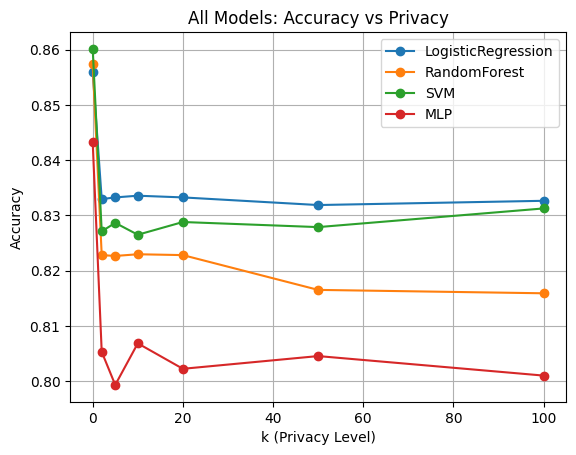

In [86]:
# Step 5.6 — Plot comparison (Accuracy)
import matplotlib.pyplot as plt

plt.figure()

for model_name in models.keys():
    subset = results_df[results_df["model"] == model_name]
    subset = subset.sort_values("k")
    
    plt.plot(subset["k"], subset["accuracy"], marker="o", label=model_name)

plt.xlabel("k (Privacy Level)")
plt.ylabel("Accuracy")
plt.title("All Models: Accuracy vs Privacy")
plt.legend()
plt.grid()

plt.show()

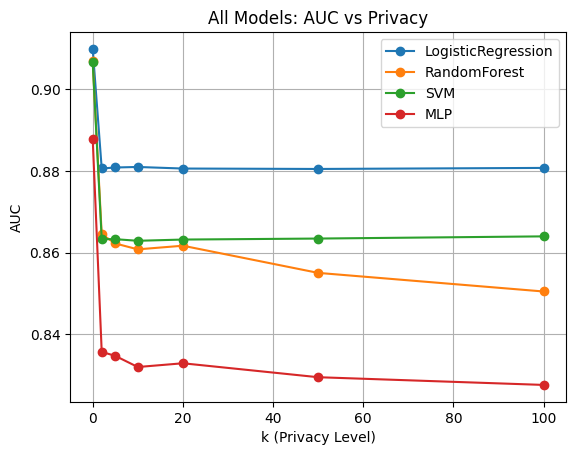

In [88]:
# Step 5.7 — Plot comparison (AUC)
plt.figure()

for model_name in models.keys():
    subset = results_df[results_df["model"] == model_name]
    subset = subset.sort_values("k")
    
    plt.plot(subset["k"], subset["auc"], marker="o", label=model_name)

plt.xlabel("k (Privacy Level)")
plt.ylabel("AUC")
plt.title("All Models: AUC vs Privacy")
plt.legend()
plt.grid()

plt.show()

### Deep Learning Model (1D CNN)

In [61]:
# Step 6.1 — Import libraries
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

In [62]:
# Step 6.2 — Fix random seeds
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

In [65]:
# Step 6.3 — Device
device = torch.device("cuda" if torch.cuda.is_available() else "mps")
print("Using device:", device)

Using device: mps


In [66]:
# Step 6.4 — Transform with preprocessor
def transform_with_preprocessor(preprocessor, X_train, X_test):
    X_train_trans = preprocessor.fit_transform(X_train)
    X_test_trans = preprocessor.transform(X_test)
    
    # convert sparse to dense if needed
    if hasattr(X_train_trans, "toarray"):
        X_train_trans = X_train_trans.toarray()
        X_test_trans = X_test_trans.toarray()
    
    return X_train_trans.astype(np.float32), X_test_trans.astype(np.float32)

In [67]:
# Step 6.5 — Reshape for CNN
def reshape_for_cnn_pytorch(X):
    # from (samples, features) -> (samples, 1, features)
    return X.reshape(X.shape[0], 1, X.shape[1]).astype(np.float32)

In [68]:
# Step 6.6 — Create Dataset class
class TabularCNNDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(np.array(y), dtype=torch.float32)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [69]:
# Step 6.7 — Build the 1D CNN model in PyTorch
class CNN1D(nn.Module):
    def __init__(self, input_length):
        super().__init__()
        
        self.features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2),
            
            nn.Conv1d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=2)
        )
        
        # compute flattened dimension automatically
        with torch.no_grad():
            dummy = torch.zeros(1, 1, input_length)
            dummy_out = self.features(dummy)
            flattened_dim = dummy_out.view(1, -1).shape[1]
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flattened_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [70]:
# Step 6.8 — Training function
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    
    for X_batch, y_batch in dataloader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device).unsqueeze(1)  # shape: (batch, 1)
        
        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * X_batch.size(0)
    
    epoch_loss = running_loss / len(dataloader.dataset)
    return epoch_loss

In [71]:
# Step 6.9 — Prediction function
def predict_model(model, dataloader, device):
    model.eval()
    
    all_probs = []
    all_preds = []
    all_true = []
    
    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            
            logits = model(X_batch)
            probs = torch.sigmoid(logits).squeeze(1).cpu().numpy()
            preds = (probs >= 0.5).astype(int)
            
            all_probs.extend(probs)
            all_preds.extend(preds)
            all_true.extend(y_batch.numpy())
    
    return np.array(all_true), np.array(all_preds), np.array(all_probs)

In [72]:
# Step 6.10 — Train + evaluate CNN
def train_evaluate_cnn_pytorch(
    data,
    preprocessor,
    epochs=10,
    batch_size=128,
    learning_rate=1e-3,
    seed=42
):
    set_seed(seed)
    
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    
    # preprocess
    X_train_trans, X_test_trans = transform_with_preprocessor(preprocessor, X_train, X_test)
    
    # reshape for Conv1d: (samples, channels=1, features)
    X_train_cnn = reshape_for_cnn_pytorch(X_train_trans)
    X_test_cnn = reshape_for_cnn_pytorch(X_test_trans)
    
    # datasets and loaders
    train_dataset = TabularCNNDataset(X_train_cnn, y_train)
    test_dataset = TabularCNNDataset(X_test_cnn, y_test)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    # model
    input_length = X_train_cnn.shape[2]
    model = CNN1D(input_length=input_length).to(device)
    
    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    
    # train
    history = []
    for epoch in range(epochs):
        train_loss = train_one_epoch(model, train_loader, criterion, optimizer, device)
        history.append({"epoch": epoch + 1, "train_loss": train_loss})
        print(f"Epoch {epoch+1}/{epochs} - train_loss: {train_loss:.4f}")
    
    # evaluate
    y_true, y_pred, y_prob = predict_model(model, test_loader, device)
    metrics = evaluate_classification(y_true, y_pred, y_prob)
    
    history_df = pd.DataFrame(history)
    return metrics, history_df, model

In [74]:
# Step 6.11 — Sanity check on original data first
cnn_metrics_original, cnn_history_original, cnn_model_original = train_evaluate_cnn_pytorch(
    data=dataset_splits["original"],
    preprocessor=preprocessor,
    epochs=10,
    batch_size=128,
    learning_rate=1e-3,
    seed=42
)

cnn_metrics_original

Epoch 1/10 - train_loss: 0.3937
Epoch 2/10 - train_loss: 0.3335
Epoch 3/10 - train_loss: 0.3247
Epoch 4/10 - train_loss: 0.3206
Epoch 5/10 - train_loss: 0.3181
Epoch 6/10 - train_loss: 0.3148
Epoch 7/10 - train_loss: 0.3129
Epoch 8/10 - train_loss: 0.3124
Epoch 9/10 - train_loss: 0.3097
Epoch 10/10 - train_loss: 0.3102


{'accuracy': 0.8547520343927529,
 'misclassification_rate': 0.14524796560724706,
 'precision': 0.753257328990228,
 'recall': 0.5899234693877551,
 'auc': 0.9139665143104765}

In [75]:
# Step 6.12 — Run PyTorch CNN across all datasets
cnn_results = []

for dataset_name, data in dataset_splits.items():
    print(f"\nRunning PyTorch CNN on {dataset_name}")
    
    metrics, history_df, model = train_evaluate_cnn_pytorch(
        data=data,
        preprocessor=preprocessor,
        epochs=10,
        batch_size=128,
        learning_rate=1e-3,
        seed=42
    )
    
    metrics["model"] = "CNN_1D_PyTorch"
    metrics["dataset"] = dataset_name
    
    if dataset_name == "original":
        metrics["k"] = 0
    else:
        metrics["k"] = int(dataset_name.split("=")[1])
    
    cnn_results.append(metrics)

cnn_results_df = pd.DataFrame(cnn_results).sort_values("k")
cnn_results_df


Running PyTorch CNN on original
Epoch 1/10 - train_loss: 0.3937
Epoch 2/10 - train_loss: 0.3335
Epoch 3/10 - train_loss: 0.3247
Epoch 4/10 - train_loss: 0.3206
Epoch 5/10 - train_loss: 0.3181
Epoch 6/10 - train_loss: 0.3148
Epoch 7/10 - train_loss: 0.3129
Epoch 8/10 - train_loss: 0.3124
Epoch 9/10 - train_loss: 0.3097
Epoch 10/10 - train_loss: 0.3102

Running PyTorch CNN on k=2
Epoch 1/10 - train_loss: 0.4337
Epoch 2/10 - train_loss: 0.3824
Epoch 3/10 - train_loss: 0.3769
Epoch 4/10 - train_loss: 0.3726
Epoch 5/10 - train_loss: 0.3709
Epoch 6/10 - train_loss: 0.3686
Epoch 7/10 - train_loss: 0.3665
Epoch 8/10 - train_loss: 0.3654
Epoch 9/10 - train_loss: 0.3645
Epoch 10/10 - train_loss: 0.3656

Running PyTorch CNN on k=5
Epoch 1/10 - train_loss: 0.4336
Epoch 2/10 - train_loss: 0.3826
Epoch 3/10 - train_loss: 0.3768
Epoch 4/10 - train_loss: 0.3717
Epoch 5/10 - train_loss: 0.3692
Epoch 6/10 - train_loss: 0.3676
Epoch 7/10 - train_loss: 0.3657
Epoch 8/10 - train_loss: 0.3653
Epoch 9/10 - 

,accuracy,misclassification_rate,precision,recall,auc,model,dataset,k
0,0.854752,0.145248,0.753257,0.589923,0.913967,CNN_1D_PyTorch,original,0
1,0.831721,0.168279,0.720149,0.492347,0.878758,CNN_1D_PyTorch,k=2,2
2,0.829725,0.170275,0.723032,0.474490,0.879072,CNN_1D_PyTorch,k=5,5
3,0.829572,0.170428,0.725394,0.470026,0.879460,CNN_1D_PyTorch,k=10,10
4,0.831414,0.168586,0.719626,0.491071,0.879073,CNN_1D_PyTorch,k=20,20
5,0.829572,0.170428,0.720192,0.477679,0.879801,CNN_1D_PyTorch,k=50,50
6,0.833257,0.166743,0.709930,0.519770,0.879142,CNN_1D_PyTorch,k=100,100


In [89]:
results_df

,accuracy,misclassification_rate,precision,recall,auc,model,dataset,k
0,0.855980,0.144020,0.739726,0.619898,0.909838,LogisticRegression,original,0
1,0.832949,0.167051,0.702020,0.531888,0.880588,LogisticRegression,k=2,2
2,0.833257,0.166743,0.702181,0.533801,0.880829,LogisticRegression,k=5,5
3,0.833564,0.166436,0.703361,0.533801,0.880958,LogisticRegression,k=10,10
4,0.833257,0.166743,0.702521,0.533163,0.880574,LogisticRegression,k=20,20
5,0.831875,0.168125,0.699578,0.528699,0.880472,LogisticRegression,k=50,50
6,0.832642,0.167358,0.700840,0.531888,0.880728,LogisticRegression,k=100,100
21,0.843237,0.156763,0.708302,0.593112,0.887854,MLP,original,0
22,0.805312,0.194688,0.613293,0.517857,0.835718,MLP,k=2,2
23,0.799324,0.200676,0.596452,0.514668,0.834744,MLP,k=5,5


In [90]:
# Step 6.13 — Merge with previous results
final_results_df = pd.concat([results_df, cnn_results_df], axis=0)
final_results_df = final_results_df.sort_values(["model", "k"])

final_results_df.head(20)

,accuracy,misclassification_rate,precision,recall,auc,model,dataset,k
0,0.854752,0.145248,0.753257,0.589923,0.913967,CNN_1D_PyTorch,original,0
1,0.831721,0.168279,0.720149,0.492347,0.878758,CNN_1D_PyTorch,k=2,2
2,0.829725,0.170275,0.723032,0.474490,0.879072,CNN_1D_PyTorch,k=5,5
3,0.829572,0.170428,0.725394,0.470026,0.879460,CNN_1D_PyTorch,k=10,10
4,0.831414,0.168586,0.719626,0.491071,0.879073,CNN_1D_PyTorch,k=20,20
5,0.829572,0.170428,0.720192,0.477679,0.879801,CNN_1D_PyTorch,k=50,50
6,0.833257,0.166743,0.709930,0.519770,0.879142,CNN_1D_PyTorch,k=100,100
0,0.855980,0.144020,0.739726,0.619898,0.909838,LogisticRegression,original,0
1,0.832949,0.167051,0.702020,0.531888,0.880588,LogisticRegression,k=2,2
2,0.833257,0.166743,0.702181,0.533801,0.880829,LogisticRegression,k=5,5


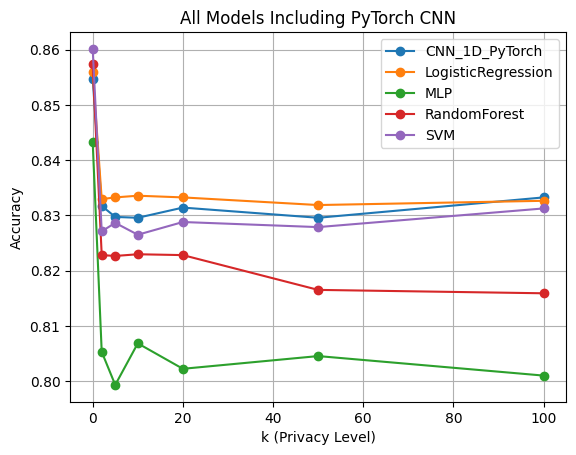

In [91]:
# Step 6.14 — Plot comparison
import matplotlib.pyplot as plt

plt.figure()

for model_name in final_results_df["model"].unique():
    subset = final_results_df[final_results_df["model"] == model_name].sort_values("k")
    plt.plot(subset["k"], subset["accuracy"], marker="o", label=model_name)

plt.xlabel("k (Privacy Level)")
plt.ylabel("Accuracy")
plt.title("All Models Including PyTorch CNN")
plt.legend()
plt.grid()
plt.show()

### Categorical QI with Mondrian-style k-anonymity

In [92]:
# Step 7.1 — Define new QI set
qi_num = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

qi_cat = [
    "workclass",
    "education",
    "marital-status",
    "occupation",
    "relationship",
    "race",
    "sex",
    "native-country"
]

qi_all = qi_num + qi_cat
sa_col = "income"

print("Total QI columns:", len(qi_all))

Total QI columns: 14


In [93]:
# Step 7.2 — Define categorical generalization rules
# 1. Workclass
workclass_map = {
    "Private": "Private",
    "Self-emp-not-inc": "Self-employed",
    "Self-emp-inc": "Self-employed",
    "Federal-gov": "Government",
    "Local-gov": "Government",
    "State-gov": "Government",
    "Without-pay": "Other",
    "Never-worked": "Other"
}

# 2. Education → broader levels
education_map = {
    "Bachelors": "Higher",
    "Masters": "Higher",
    "Doctorate": "Higher",
    
    "HS-grad": "Secondary",
    "Some-college": "Secondary",
    
    "11th": "Basic",
    "10th": "Basic",
    "9th": "Basic",
    "7th-8th": "Basic",
    "5th-6th": "Basic",
    "1st-4th": "Basic",
    "Preschool": "Basic"
}

# 3. Marital status
marital_map = {
    "Married-civ-spouse": "Married",
    "Married-AF-spouse": "Married",
    "Married-spouse-absent": "Married",
    
    "Never-married": "Single",
    
    "Divorced": "Separated",
    "Separated": "Separated",
    "Widowed": "Separated"
}

# 4. Occupation
occupation_map = {
    "Tech-support": "Tech",
    "Craft-repair": "Manual",
    "Other-service": "Service",
    "Sales": "Sales",
    "Exec-managerial": "Management",
    "Prof-specialty": "Professional",
    "Handlers-cleaners": "Manual",
    "Machine-op-inspct": "Manual",
    "Adm-clerical": "Clerical",
    "Farming-fishing": "Manual",
    "Transport-moving": "Manual",
    "Priv-house-serv": "Service",
    "Protective-serv": "Service",
    "Armed-Forces": "Other"
}

# 5. Native country → region
def country_to_region(country):
    if country == "United-States":
        return "North-America"
    elif country in ["Canada"]:
        return "North-America"
    elif country in ["Mexico"]:
        return "Central-America"
    else:
        return "Other"

In [94]:
# Step 7.3 — Apply categorical generalization
def generalize_categorical(df):
    df = df.copy()
    
    df["workclass"] = df["workclass"].map(workclass_map).fillna("Other")
    df["education"] = df["education"].map(education_map).fillna("Other")
    df["marital-status"] = df["marital-status"].map(marital_map).fillna("Other")
    df["occupation"] = df["occupation"].map(occupation_map).fillna("Other")
    
    df["native-country"] = df["native-country"].apply(country_to_region)
    
    return df

In [95]:
# Step 7.4 — Prepare dataset with categorical QI
df_cat_qi = df.copy()

df_cat_qi = generalize_categorical(df_cat_qi)

df_cat_qi.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,Government,77516,Higher,13,Single,Clerical,Not-in-family,White,Male,2174,0,40,North-America,<=50K
1,50,Self-employed,83311,Higher,13,Married,Management,Husband,White,Male,0,0,13,North-America,<=50K
2,38,Private,215646,Secondary,9,Separated,Manual,Not-in-family,White,Male,0,0,40,North-America,<=50K
3,53,Private,234721,Basic,7,Married,Manual,Husband,Black,Male,0,0,40,North-America,<=50K
4,28,Private,338409,Higher,13,Married,Professional,Wife,Black,Female,0,0,40,Other,<=50K


In [96]:
# Step 7.5 — Apply Mondrian ONLY on numerical QI
work_df_cat = df_cat_qi[qi_all + [sa_col]].copy()

anon_cat_results = {}

for k in [2, 5, 10, 20, 50, 100]:
    anon_qi_df, partitions = anonymize_with_mondrian(
        work_df_cat,
        qi_num,   # only numeric used for splitting
        sa_col,
        k
    )
    
    full_df = df_cat_qi.copy()
    
    for col in qi_num:
        full_df[col] = anon_qi_df[col]
    
    anon_cat_results[k] = full_df

### Evaluate ML with Categorical + Numerical QI

In [97]:
# Step 8.1 — Prepare mixed-QI datasets for ML
prepared_cat_results = {
    k: prepare_dataset_for_ml(df_k, qi_num, target_col)
    for k, df_k in anon_cat_results.items()
}

In [98]:
# Step 8.2 — Build dataset splits
dataset_splits_cat = {}

for k, df_k in prepared_cat_results.items():
    dataset_splits_cat[f"k={k}"] = build_train_test_dict(
        df_k,
        train_idx,
        test_idx
    )

In [99]:
# Step 8.3 — Run all classical models again
cat_results = []

for model_name, model in models.items():
    print(f"[CAT QI] Running model: {model_name}")
    
    for dataset_name, data in dataset_splits_cat.items():
        X_train = data["X_train"]
        X_test = data["X_test"]
        y_train = data["y_train"]
        y_test = data["y_test"]
        
        pipeline = Pipeline(steps=[
            ("preprocessor", preprocessor),
            ("classifier", model)
        ])
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        y_prob = pipeline.predict_proba(X_test)[:, 1]
        
        metrics = evaluate_classification(y_test, y_pred, y_prob)
        
        metrics["model"] = model_name
        metrics["dataset"] = dataset_name
        metrics["k"] = int(dataset_name.split("=")[1])
        metrics["setting"] = "Mixed_QI"
        
        cat_results.append(metrics)

cat_results_df = pd.DataFrame(cat_results)

[CAT QI] Running model: LogisticRegression
[CAT QI] Running model: RandomForest
[CAT QI] Running model: SVM
[CAT QI] Running model: MLP


/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/Users/alimmisbullah/miniconda3/envs/datasecurity/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2

In [100]:
# Step 8.4 — Add label to previous results
results_df["setting"] = "Numeric_QI"

In [101]:
# Step 8.5 — Combine everything
combined_results = pd.concat([results_df, cat_results_df], axis=0)
combined_results = combined_results.sort_values(["model", "setting", "k"])

combined_results.head(20)

,accuracy,misclassification_rate,precision,recall,auc,model,dataset,k,setting
0,0.827576,0.172424,0.688400,0.518495,0.870190,LogisticRegression,k=2,2,Mixed_QI
1,0.827576,0.172424,0.688400,0.518495,0.870513,LogisticRegression,k=5,5,Mixed_QI
2,0.827422,0.172578,0.687817,0.518495,0.870848,LogisticRegression,k=10,10,Mixed_QI
3,0.827115,0.172885,0.686655,0.518495,0.870422,LogisticRegression,k=20,20,Mixed_QI
4,0.826347,0.173653,0.684388,0.517219,0.870377,LogisticRegression,k=50,50,Mixed_QI
5,0.826501,0.173499,0.686542,0.514031,0.870438,LogisticRegression,k=100,100,Mixed_QI
0,0.855980,0.144020,0.739726,0.619898,0.909838,LogisticRegression,original,0,Numeric_QI
1,0.832949,0.167051,0.702020,0.531888,0.880588,LogisticRegression,k=2,2,Numeric_QI
2,0.833257,0.166743,0.702181,0.533801,0.880829,LogisticRegression,k=5,5,Numeric_QI
3,0.833564,0.166436,0.703361,0.533801,0.880958,LogisticRegression,k=10,10,Numeric_QI


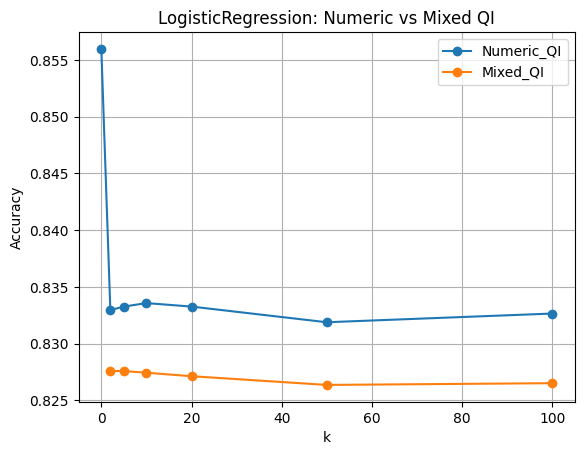

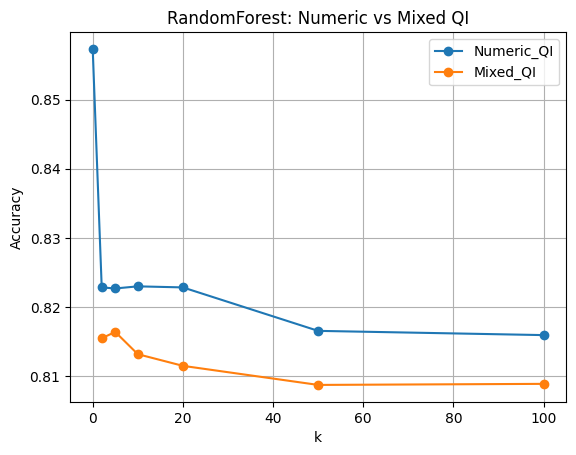

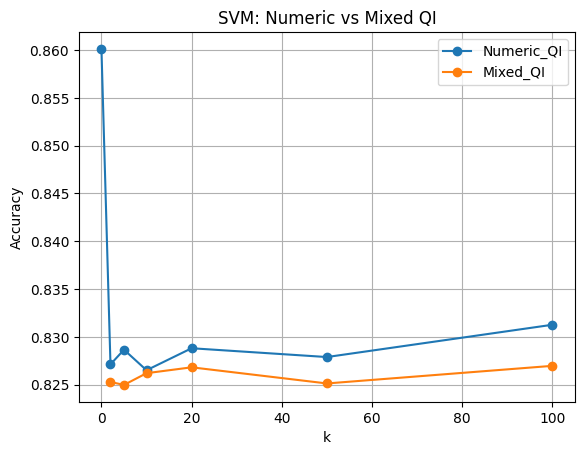

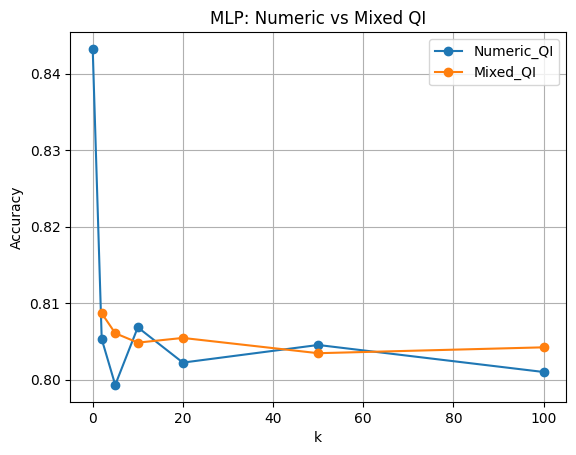

In [102]:
# Step 8.6 — Compare Numeric vs Mixed QI
import matplotlib.pyplot as plt

for model_name in models.keys():
    plt.figure()
    
    subset = combined_results[combined_results["model"] == model_name]
    
    for setting in ["Numeric_QI", "Mixed_QI"]:
        sub = subset[subset["setting"] == setting]
        sub = sub.sort_values("k")
        
        plt.plot(sub["k"], sub["accuracy"], marker="o", label=setting)
    
    plt.title(f"{model_name}: Numeric vs Mixed QI")
    plt.xlabel("k")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.grid()
    
    plt.show()